In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./Encoded_EDA_DONE.csv")


In [2]:
df

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,month,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,0,56,3,1,0,0,0,0,1,6,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,1,57,7,1,3,0,0,0,1,6,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,2,37,7,1,3,0,1,0,1,6,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,3,40,0,1,1,0,0,0,1,6,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,4,56,7,1,3,0,0,1,1,6,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35599,41183,73,5,1,5,0,1,0,0,7,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
35600,41184,46,1,1,5,0,0,0,0,7,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
35601,41185,56,5,1,6,0,1,0,0,7,...,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
35602,41186,44,9,1,5,0,0,0,0,7,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1


In [3]:
from sklearn.model_selection import train_test_split
# from sklearn.metrics 

In [4]:
df['y'].value_counts()
X = df.drop('y',axis=1)
y = df['y']

In [5]:
# splitting the data
X_train, X_test , y_train , y_test = train_test_split(X, y , test_size=0.2, random_state=42)

In [6]:
#  smote
from imblearn.over_sampling import SMOTE
sm = SMOTE()

X_train_res, y_train_res = sm.fit_resample(X_train,y_train)

## feature scalling

In [7]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()

X_train_scaled = Scaler.fit_transform(X_train_res) 
X_test_scaled = Scaler.transform(X_test)

## training random forest

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

random_f_model = RandomForestClassifier(random_state= 42, n_estimators=100)
#  in this model no need of scaled data
random_f_model.fit(X_train_res,y_train_res)
y_pred_rf = random_f_model.predict(X_test)

print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf ))
print()
print("classification report:", classification_report(y_test, y_pred_rf))
print()
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy:  0.8494593455975284

classification report:               precision    recall  f1-score   support

           0       0.92      0.91      0.91      6231
           1       0.41      0.45      0.43       890

    accuracy                           0.85      7121
   macro avg       0.66      0.68      0.67      7121
weighted avg       0.86      0.85      0.85      7121


Confusion matrix:
 [[5648  583]
 [ 489  401]]


# K NEAREST NEIGHBOUR

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled,y_train_res)

y_pred_knn = knn_model.predict(X_test_scaled)

In [10]:
print("knn accuracy : ",accuracy_score(y_test, y_pred_knn))
print()
print("classification report : \n",classification_report(y_test, y_pred_knn))

knn accuracy :  0.7691335486588963

classification report : 
               precision    recall  f1-score   support

           0       0.92      0.80      0.86      6231
           1       0.28      0.53      0.37       890

    accuracy                           0.77      7121
   macro avg       0.60      0.67      0.61      7121
weighted avg       0.84      0.77      0.80      7121



## SVM ( SUpport Vector Machine )

In [11]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf',random_state=42)
svm_model.fit(X_train_scaled,y_train_res)

# prediction
y_pred_svm = svm_model.predict(X_test_scaled)






In [12]:
# evaluate
print("Accuracy SVM :",accuracy_score(y_test , y_pred_svm))
print()
print("Classification Report :",classification_report(y_test , y_pred_svm))
print()
print("confusion matrix\n",confusion_matrix(y_test , y_pred_svm))
print()

Accuracy SVM : 0.8264288723493891

Classification Report :               precision    recall  f1-score   support

           0       0.93      0.87      0.90      6231
           1       0.37      0.55      0.44       890

    accuracy                           0.83      7121
   macro avg       0.65      0.71      0.67      7121
weighted avg       0.86      0.83      0.84      7121


confusion matrix
 [[5397  834]
 [ 402  488]]



## XGBoost

In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier()

xgb_model.fit(X_train_res,y_train_res)

y_pred_xg = xgb_model.predict(X_test)



In [14]:
print("XGBoosting accuracy: ",accuracy_score(y_test,y_pred_xg))
print()
print("classification report : \n: ",classification_report(y_test,y_pred_xg))

XGBoosting accuracy:  0.84089313298694

classification report : 
:                precision    recall  f1-score   support

           0       0.92      0.89      0.91      6231
           1       0.39      0.49      0.44       890

    accuracy                           0.84      7121
   macro avg       0.66      0.69      0.67      7121
weighted avg       0.86      0.84      0.85      7121



In [15]:
models = ['random forest','k nearest neighbor','SVM','XGBoost']

accuracy = [
    # accuracy_score(y_test, y_pred),        # logistic from earlier
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_xg)

]

comparison = pd.DataFrame({'Model':models, 'Accuracy':accuracy})
print(comparison.sort_values(by='Accuracy',ascending=False))



                Model  Accuracy
0       random forest  0.849459
3             XGBoost  0.840893
2                 SVM  0.826429
1  k nearest neighbor  0.769134


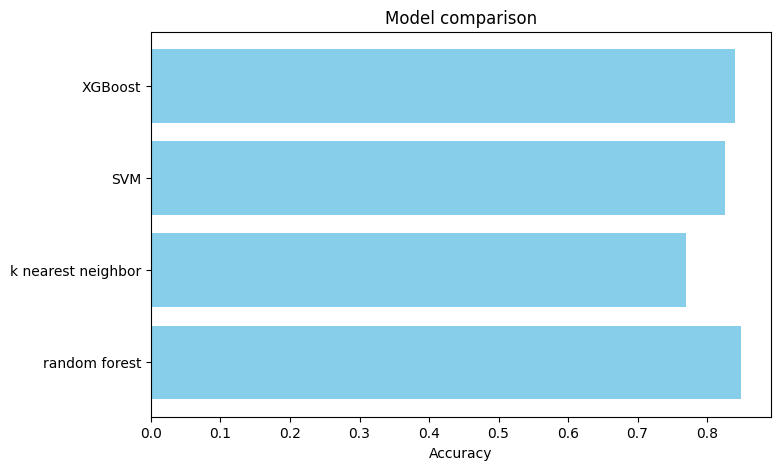

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(comparison['Model'], comparison['Accuracy'], color= 'skyblue' )
plt.xlabel("Accuracy")
plt.title("Model comparison")
plt.show()

In [17]:

l1=["randomforest","knn","svm","xgboost"]


from sklearn.metrics import precision_score, recall_score, f1_score

comparison = []

for name, preds in zip(l1, [y_pred_rf, y_pred_knn, y_pred_svm, y_pred_xg]):
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Yes)': precision_score(y_test, preds),
        'Recall (Yes)': recall_score(y_test, preds),
        'F1-Score (Yes)': f1_score(y_test, preds)
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison).sort_values(by='F1-Score (Yes)', ascending=False)
print(comparison_df)


          Model  Accuracy  Precision (Yes)  Recall (Yes)  F1-Score (Yes)
2           svm  0.826429         0.369138      0.548315        0.441230
3       xgboost  0.840893         0.391808      0.494382        0.437158
0  randomforest  0.849459         0.407520      0.450562        0.427962
1           knn  0.769134         0.278496      0.532584        0.365741


In [18]:
for a , cr , cm, i in accuracy,conf_matrix,classif_report,l1:
    print(f"------------{i}---------------")
    print(a)
    print()
    print(cr)
    print()
    print(cm)
    print("---------------------------")

NameError: name 'conf_matrix' is not defined

In [ ]:
# SVM model is selected